## 0. Preprocessing for the OPLS data

/Users/xiaogangyang/pyprojects/pxrr/.pixi/envs/default/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/xiaogangyang/pyprojects/pxrr/.pixi/envs/default/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/xiaogangyang/pyprojects/pxrr/.pixi/envs/default/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/xiaogangyang/pyprojects/pxrr/.pixi/envs/default/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/Users/xiaogangyang/pyprojects/pxrr/.pixi/envs/default/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.as

[51218 51219 51220 51221 51222 51223 51224 51225 51226 51227 51228 51229
 51230 51231]
84 3
3.646537087758402
no chamber data
sum frames of each scan
loading done
id =  51218
qxy0 =  0.04061061973771442
sample height =  -0.9753980153572996
84 3
3.6492434358596997
no chamber data
sum frames of each scan
loading done
id =  51219
qxy0 =  0.04061061973771419
sample height =  -1.975403952857306
84 3
3.648926973342915
no chamber data
sum frames of each scan
loading done
id =  51220
qxy0 =  0.06068655778731455
sample height =  -0.9753980153572996
84 3
3.6529480266571244
no chamber data
sum frames of each scan
loading done
id =  51221
qxy0 =  0.06063879596232328
sample height =  -1.975403952857306
84 3
3.6502148977915643
no chamber data
sum frames of each scan
loading done
id =  51222
qxy0 =  0.08068277849996167
sample height =  -0.9753980153572996
84 3
3.651621672312438
no chamber data
sum frames of each scan
loading done
id =  51223
qxy0 =  0.08057133497953932
sample height =  -1.97540395285

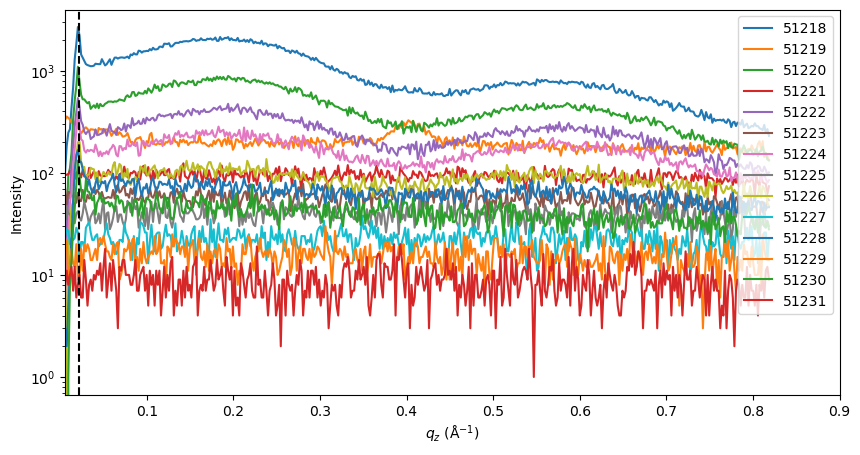

In [ ]:
import numpy as np
from pxrr.nsls2_opls_input import NSLS2OPLSInput

opls = NSLS2OPLSInput(
    path='/Users/xiaogangyang/data/opls-pxrr/',
    sdd=680 / 1000,
    pxsize=172e-6,
    bad_pixel=(100, 269),
    roi_y=195 - 111,
    roi_x=41 + 9,
    roi_dy=3,
)

# alternating sample / chamber-bkg pairs
ids = np.arange(51218, 51231 + 1)
sample_scans = ids[0::2].tolist()
bkg_scans    = ids[1::2].tolist()

opls.load_data(sample_id_set=ids)
opls.plot()
opls.save_gixos_1d()

# emit YAML config that the next steps can consume directly
metadata_file = opls.save_metadata_yaml(
    yaml_path="./opls_full/gixos-process_config_1d.yaml",
    sample_scans=sample_scans,
    bkg_scans=bkg_scans,
    gixs_path=opls.path + "gixos2/",
    path_out="./testing_data/output/opls_full/",
)

## Pseudo-XRR from 1D GIXOS linecuts (OPLS / NSLS-II 12ID)

Step-by-step workflow analogous to `pXRR_step2.ipynb`, using the new pxrr
(extended capillary wave model) API and the OPLS metadata configuration
(`opls_1d/gixos-process_config_1d.yaml`).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import pi

from pxrr.eCWM import *
from pxrr.data_io import (
    load_gixos_from_meta,
    save_metadata_yaml,
    export_gixos_nxs,
    load_gixos_nxs,
    export_orso,
)
from pxrr.gixos import (
    binning_GIXOS_tt,
    remove_negative_2theta,
    GIXOS_th2q,
    GIXOS_background_corr,
    GIXOS_qxy_dependence,
    GIXOS2R,
)
from pxrr.helpers import make_filename

### 2. Load configuration and data

Load sample and chamber-background GIXOS data directly from the OPLS YAML
configuration. All metadata is attached to the GIXOS dictionaries under
`["metadata"]`; the YAML file is no longer needed after this point.

In [ ]:
# metadata_file was produced by cell 2 (opls.save_metadata_yaml)
GIXOSdata, GIXOSbkg = load_gixos_from_meta(metadata_file)

### 3. Corrections

- vertical binning in `tt` (beta)
- remove negative 2theta rows
- convert angular axes to Q

In [ ]:
GIXOSdata = binning_GIXOS_tt(GIXOSdata)
GIXOSbkg  = binning_GIXOS_tt(GIXOSbkg)

GIXOSdata = remove_negative_2theta(GIXOSdata)
GIXOSbkg  = remove_negative_2theta(GIXOSbkg)

GIXOSdata_q = GIXOS_th2q(GIXOSdata)
GIXOSbkg_q  = GIXOS_th2q(GIXOSbkg)

### 4. Background subtraction

Subtract chamber background and a constant bulk background determined from
the high-Qz average (`bulkbkg_mode=0`, `bulkbkg_const_mode=1`).

In [ ]:
GIXOS_ana = GIXOS_background_corr(
    GIXOSdata_q,
    GIXOSbkg_q,
    bulkbkg_mode=0,
    bulkbkg_const_mode=1,
    bulkbkg_const_qz_lb=0.7,
    plot=True,
)

### 5. Save / reload corrected GIXOS (NeXus HDF5)

Store the corrected GIXOS dictionary (data + metadata) so the analysis can
be resumed later. The reloaded copy `GIXOS_back` is only shown for demo.

In [ ]:
outgixosfile = make_filename(GIXOS_ana["metadata"], suffix="gixos.h5")
export_gixos_nxs(GIXOS_ana, outgixosfile)

GIXOS_back = load_gixos_nxs(outgixosfile)
print("reloaded keys:", list(GIXOS_back.keys()))

### 6. Qxy dependence fit

Fit the bending modulus `kappa` from the Qxy dependence of the diffuse
intensity at the Qz values listed in `metadata['dependency']['qz_selected']`.
Subsequent operations write back into `GIXOS_ana` (shared dict).

In [ ]:
_, qxy_dependence_fit = GIXOS_qxy_dependence(
    GIXOS_ana,
    GIXOS_ana["metadata"]["dependency"]["qz_selected"],
    row_window=3,
    fit_kappa=True,
)

### 7. Convert GIXOS to pseudo-reflectivity and structure factor

Apply the eCWM roughness factors at the selected `qxy0` positions to obtain
`R(Qz)`, `|Phi(Qz)|^2`, and the specular roughness factor `Psi_R(Qz)`.

In [ ]:
_ = GIXOS2R(
    GIXOS_ana,
    transmission_corr=True,
    footprint_effect=False,
    use_approx=True,
)

### 8. Export updated configuration YAML

Save the metadata back to YAML (in the same structure as the input config),
now including the fitted bending modulus `kappa`.

In [ ]:
configfilename = make_filename(GIXOS_ana["metadata"], suffix="cfg.yaml")
save_metadata_yaml(GIXOS_ana["metadata"], configfilename)
print("config written:", configfilename)

### 9. Export ORSO files

- `refl`  : pseudo-reflectivity R(Qz)
- `SF`    : structure factor |Phi(Qz)|^2
- `GIXOS` : background-corrected GIXOS (I0 * R*)

In [ ]:
_ = export_orso(GIXOS_ana, which="refl")
_ = export_orso(GIXOS_ana, which="SF")
_ = export_orso(GIXOS_ana, which="GIXOS")